**GROUP NUMBER** : 37

**FULL NAME**: ADEFEMI ADELUGBA                                   

**DATASET**: TELCO CUSTOMER CHURN

**DEPTH TRACK**: CLASSIFICATION DEPTH

**TEAM MEMBERS**:
- BALOGUN BUKUNMI PHILP
- LAWRENCE GLORIA C.
- ADEFEMI ADELUGBA
- DURU AMARACHI
- GOODNESS CHIZARAM SAMUEL
- NGBEKEN NICHOLAS ONYEKACHUKWU
- ADESHINA MARIAM OMOWUNMI
- NWOSU OZIOMA NNEKA

**FINAL MODEL:** Logistic Regression, with the decision threshold tuned to about 0.14 (cost-weighted, missed churner treated as 5x costlier than a wasted retention offer)

**STRATIFIED DUMMY F1/ROC AUC:** 0.2773 / 0.5074

**FINAL MODEL F1/ROC AUC**: 0.5834 / 0.8335

**LEAKAGE COLUMNS DROPPED:** None found (customerID was dropped as an identifier, not because it leaked the answer)

**FULL RUN TIME ON COLAB:** 1min 30Secs

In [1]:
import time
notebook_start_time = time.time()

##**PART 1:  DATA FOUNDATION**




####**STEP 1A**: LOAD THE DATASET FROM KAGGLE INSIDE THE NOTEBOOK.

In [2]:
#INSATLLING KAGGLEHUB
!pip install kagglehub

In [3]:
#GETTING AUTHENTICATION FROM KAGGLEHUB
import kagglehub
kagglehub.login()

In [4]:
#DOWNLOADING THE DATASET.
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Dataset downloaded to: /kaggle/input/telco-customer-churn


In [5]:
#KNOWING THE FILE NAME.
import os
print(os.listdir(path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [6]:
#LOADING THE DATASET
import pandas as pd
file_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(file_path)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


####**STEP 1B**: PUSH OUR DATA INTO SQLITE.

In [7]:
#importing sqlite.
import sqlite3

In [8]:
#creating a connection to a sqlite database
conn = sqlite3.connect("telco_churn.db")

In [9]:
#putting our dataframe into sqlite and name it customers
df.to_sql("customers", conn, if_exists="replace", index=False)

7043

####**STEP 2:** RUNNING THREE SQL QUERIES THAT REVEAL SOMETHING USEFUL FOLLOWED BY A MARKDOWN CELL EXPLAINING WHAT WE LEARNT.

In [10]:
#QUERY 1 : HOW MANY CUSTOMERS CHURNED?
# Count customers in each churn category
query1 = """
SELECT Churn, COUNT(*) AS customer_count
FROM customers
GROUP BY Churn;
"""
result1 = pd.read_sql_query(query1, conn)
print(result1)

  Churn  customer_count
0    No            5174
1   Yes            1869


**SQL QUERY 1: MARKDOWN EXPLANATION CELL:**

The query shows that 5,174 customers did not churn, while 1,869 customers churned. This means that approximately 73.5% of customers stayed with the company, while approximately 26.5% left. The target variable is therefore not evenly distributed, which is important because we will need to consider class imbalance when building our classification models later in the project.


In [11]:
# QUERY 2: DOES THE TYPE OF CONTRACT APPEAR TO BE RELATED TO CUSTOMER CHURN?
query2 = """
SELECT
    Contract,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate_pct
FROM customers
GROUP BY Contract
ORDER BY churn_rate_pct DESC;
"""

result2 = pd.read_sql_query(query2, conn)
result2

,Contract,total_customers,churned_customers,churn_rate_pct
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


**SQL QUERY 2: MARKDOWN EXPLANATION CELL**:

a.) **calculating the churn percentage within each contract type:**

month-to-month = 2220 + 1655 =3875

one year = 1307 + 166 = 1473

two year = 1647 + 48 = 1695

b.) **percentage:**

month-to-month = 1655/3875 = 42.7%

one year = 166/1473 = 11.3%

two year = 48/1695 = 2.8%

The results show a clear difference in customer churn across contract types. Among month-to-month customers, 1,655 out of 3,875 customers churned, which is approximately 42.7%. For one-year contracts, 166 out of 1,473 customers churned, approximately 11.3%. For two-year contracts, only 48 out of 1,695 customers churned, approximately 2.8%.

This suggests that contract type is strongly associated with customer churn in this dataset. Month-to-month customers have a much higher observed churn rate than customers with one-year or two-year contracts. We will investigate this relationship further during exploratory data analysis and model building.


**SQL QUERY 3: MARKDOWN EXPLANATION CELL:**

This query combines contract type and internet service to identify customer segments with both high churn and potential monthly revenue exposure.

The month-to-month fiber-optic segment stands out in the results. It contains 2,128 customers, of whom 1,162 churned, giving an observed churn rate of 54.61%. The monthly charges associated with these churned customers total 100,482.

This shows why looking at churn rate alone may not be enough for a business. A customer segment can have a high churn rate, but the potential financial impact also depends on the number of customers and their monthly charges. The results therefore give us a useful business perspective that we can investigate further during the exploratory analysis and classification stages.


In [12]:
## query 3:CHURN + REVENUE EXPOSURE:WHICH CUSTOMER SEGMENTS HAS BOTH HIGH CHURN AND HIGH MONTHLY REVENUE AT RISK?
query3 = """
SELECT
    Contract,
    InternetService,
    COUNT(*) AS customer_count,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS churn_rate_pct,
    ROUND(SUM(CASE WHEN Churn = 'Yes' THEN MonthlyCharges ELSE 0 END), 2)
        AS churned_customers_monthly_charges
FROM customers
GROUP BY Contract, InternetService
HAVING COUNT(*) >= 50
ORDER BY churned_customers_monthly_charges DESC;
"""

result3 = pd.read_sql_query(query3, conn)

result3

,Contract,InternetService,customer_count,churned_customers,churn_rate_pct,churned_customers_monthly_charges
0,Month-to-month,Fiber optic,2128,1162,54.61,100482.00
1,Month-to-month,DSL,1223,394,32.22,18367.25
2,One year,Fiber optic,539,104,19.29,10571.95
3,One year,DSL,570,53,9.30,3356.25
4,Two year,Fiber optic,429,31,7.23,3246.10
5,Month-to-month,No,524,99,18.89,1997.85
6,Two year,DSL,628,12,1.91,805.70
7,One year,No,364,9,2.47,190.25
8,Two year,No,638,5,0.78,113.50


####**STEP 3:** **PERFORM EDA** (**EXPLORATORY DATA ANALYSIS**)
  

*   SHAPE
*  TYPES


*  MISSING VALUES
*  TARGET DISTRIBUTION


*  THREE TO FIVE FEATURE DISTRIBUTION







In [13]:
# SHAPE : 7043 ROWS AND 21 COLUMNS.
df.shape

(7043, 21)

In [14]:
# TYPES
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [15]:
# MISSING VALUES
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [16]:
# TARGET DISTRIBUTION.
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


**THREE- FIVE FEATURE DISTRIBUTIONS**

1. tenure             -      how long customers have stayed.
2. monthly charges     -      what customers are charged monthly.
3. contract           -      customer's contract type.
4. internet service-         customers internet service type







In [17]:
# TENURE
df["tenure"].describe()


,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


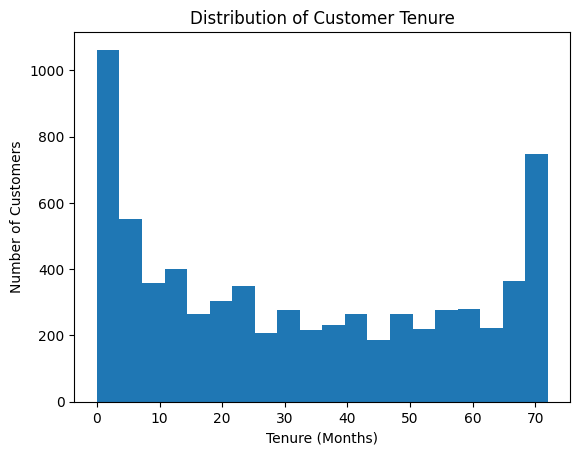

In [18]:
# DISTRIUTION CHART FOR TENURE
import matplotlib.pyplot as plt

plt.hist(df["tenure"], bins=20)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

In [19]:
# MONTHLYCHARGES
df["MonthlyCharges"].describe()

,MonthlyCharges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


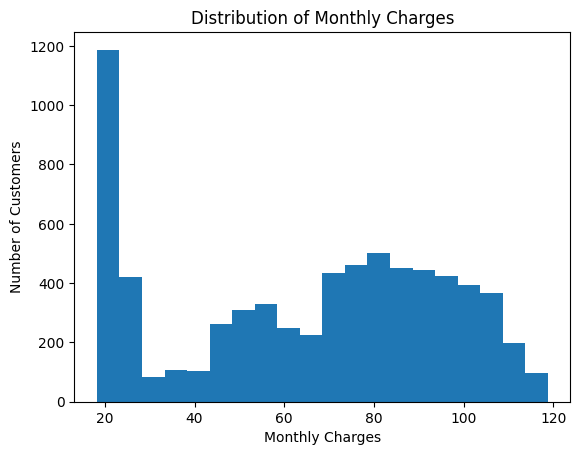

In [20]:
#DISTRIBUTION CHART FOR MONTHLYCHARGES
plt.hist(df["MonthlyCharges"], bins=20)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

In [21]:
# CONTRACT
df["Contract"].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


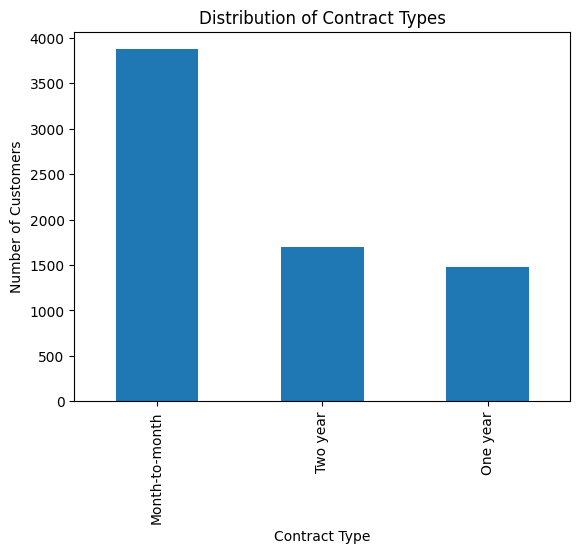

In [22]:
# DISTRIBUTION CHART FOR CONTRACT
import matplotlib.pyplot as plt

df["Contract"].value_counts().plot(kind="bar")

plt.title("Distribution of Contract Types")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

In [23]:
#INTERNETSERVICE
df["InternetService"].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2421
No,1526


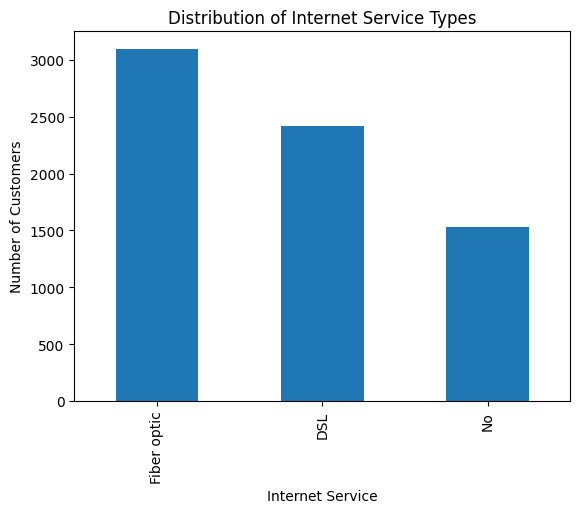

In [24]:
#DISTRIBUTION CHART FOR INTERNETSERVICE
import matplotlib.pyplot as plt

df["InternetService"].value_counts().plot(kind="bar")

plt.title("Distribution of Internet Service Types")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

####**STEP 4:** CLEAN THE DATA, JUSTFIFYING EVERY STEP IN MARKDOWN. NO BLANCKET fillna. IF YOU DROP ROWS, EXPLAIN WHY.
  **Data Cleaning**

Before cleaning the dataset, we will identify columns that require correction or transformation based on the findings from the exploratory data analysis. Each cleaning decision will be justified to ensure that we do not make unnecessary changes to the data.


In [25]:
#CHECK TOTALCHARGES
df["TotalCharges"].head(10)

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
5,820.5
6,1949.4
7,301.9
8,3046.05
9,3487.95


In [26]:
#CHECKING FOR BLANK VALUES
df["TotalCharges"].value_counts().head()

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8


In [27]:
#CHECKING FOR EMPTY OR WHITE-SPACE ENTRIES
(df["TotalCharges"].astype(str).str.strip() == "").sum()

np.int64(11)

**MARKDOWN JUSTIFICATION**

a.) **Cleaning `TotalCharges`**

The `TotalCharges` column is stored as an object data type even though it represents numerical customer charges. Our inspection found 11 blank or whitespace-only values in this column.

Because `TotalCharges` is required as a numerical feature for later analysis and modelling, these blank entries cannot be directly converted to numbers. We will remove the 11 affected rows because the values are unavailable and there is no reliable value in the dataset that can be used to replace them without introducing assumptions.

This is a targeted removal of only the rows affected by the missing `TotalCharges` values, rather than using a blanket `fillna()` approach.


In [28]:
# REMOVING THE 11 ROWS
df = df[df["TotalCharges"].astype(str).str.strip() != ""]

In [29]:
#CHECKING HOW MANY ROWS REMAIN
df.shape

(7032, 21)

b.) **Converting `TotalCharges` to Numeric**

After removing the 11 rows with blank `TotalCharges` values, the remaining values represent numerical customer charges. We will convert this column from `object` to a numeric data type so that it can be correctly used in numerical analysis and machine learning.


In [30]:
#COVERTING THE DATA TYPE ROBUSTLY
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
# Remove rows where TotalCharges became NaN due to coercion
df.dropna(subset=["TotalCharges"], inplace=True)

In [31]:
#CHECKING THE DATA TYPE IF IT HAS BEEN CORRECTED
df["TotalCharges"].dtype

dtype('float64')

In [32]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


c.) **Checking for Duplicate Rows**

We will check the dataset for duplicate rows to ensure that the same customer record has not been unintentionally repeated. Duplicate records could cause certain customers to have more influence during analysis and model training.


In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


 **DATA CLEANING CONCLUSION**

The dataset was cleaned based on the issues identified during the exploratory analysis. The `TotalCharges` column contained 11 blank values, so the 11 affected rows were removed because there was no reliable value available for replacement. The remaining `TotalCharges` values were converted from `object` to `float64` so that the column could be used correctly for numerical analysis and modelling.

A final missing-value check confirmed that there are no missing values remaining, and a duplicate check confirmed that there are no duplicate rows. No blanket `fillna()` method was used.


##**PART 2: FEATURE ENGINEERING AND ENCODING**

####**PART 2.1 - FEATURES**

a.) **Feature 1: IsHighRiskProfile**

**Business Reasoning:** Flags customers with Fiber optic service, Month-to-month contracts, and no TechSupport as a specific higher-risk segment for churn analysis.

b.) **Feature 2: AvgMonthlyToTotalRatio**

**Business Reasoning:** Captures the relationship between a customer's TotalCharges and tenure, providing an additional measure of their spending pattern over their time with the company.

In [35]:
# Feature 1: High-risk interaction
df['IsHighRiskProfile'] = (
    (df['InternetService'] == 'Fiber optic') &
    (df['Contract'] == 'Month-to-month') &
    (df['TechSupport'] == 'No')
).astype(int)

# Feature 2: AvgMonthlySpend Efficiency
import numpy as np
df['TotalChargesPerTenure'] = df['TotalCharges'] / df['tenure'].replace(0, np.nan)

print(f"High-risk customers: {df['IsHighRiskProfile'].sum()} out of {len(df)} ({df['IsHighRiskProfile'].mean()*100:.1f}%)")
df[['tenure', 'InternetService', 'Contract', 'TechSupport', 'IsHighRiskProfile']].head(8)

High-risk customers: 1796 out of 7032 (25.5%)


,tenure,InternetService,Contract,TechSupport,IsHighRiskProfile
0,1,DSL,Month-to-month,No,0
1,34,DSL,One year,No,0
2,2,DSL,Month-to-month,No,0
3,45,DSL,One year,Yes,0
4,2,Fiber optic,Month-to-month,No,1
5,8,Fiber optic,Month-to-month,No,1
6,22,Fiber optic,Month-to-month,No,1
7,10,DSL,Month-to-month,No,0


In [36]:
df.shape


(7032, 23)

In [37]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'IsHighRiskProfile', 'TotalChargesPerTenure']


c.) **Feature 3: TenureGroup**

**Business Reasoning:** Groups customers into tenure ranges to identify differences in churn behaviour between newer and longer-standing customers.

d.) **Feature 4: NumAddOnServices**

**Business Reasoning:** Counts the additional services subscribed to by each customer, providing a measure of customer engagement and service adoption that may help explain churn.

In [38]:
# Add TenureGroup
df['TenureGroup'] = pd.cut(df['tenure'], bins=[-1, 12, 36, 72], labels=['New_0-12m', 'Mid_13-36m', 'Loyal_37-72m'])

# Add NumAddOnServices
add_on_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
df['NumAddOnServices'] = (df[add_on_cols] == 'Yes').sum(axis=1)

print(df.shape) # Should now be (7032, 25) = 21 original + 4 new
print(df[['TenureGroup', 'NumAddOnServices', 'IsHighRiskProfile', 'TotalChargesPerTenure']].head())

(7032, 25)
    TenureGroup  NumAddOnServices  IsHighRiskProfile  TotalChargesPerTenure
0     New_0-12m                 1                  0              29.850000
1    Mid_13-36m                 2                  0              55.573529
2     New_0-12m                 2                  0              54.075000
3  Loyal_37-72m                 3                  0              40.905556
4     New_0-12m                 0                  1              75.825000


#### **Part 2.2 - ENCODING CATEGORICAL COLUMNS**
We have 16 categorical columns. So here is the strategy:
- Binary Yes/No and Male/Female (gender, Partner, Dependents, PhoneService, PaperlessBilling, Churn): Label encoding 0/1 for efficiency. This is identical to one-hot with drop_first.
- Multi-category (MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaymentMethod, TenureGroup): One-hot encoding to avoid false ordinal ordering. We use drop_first=True to avoid dummy variable trap and reduce dimensionality for K-Means.

Note: customerID is excluded because it is a unique identifier rather than a meaningful customer characteristic. Including it would add arbitrary information to the clustering and classification models.

In [39]:
from sklearn.preprocessing import LabelEncoder

# Make a copy for modeling
df_model = df.copy()

# 1. Binary columns - manual mapping for interpretability
binary_map = {'Yes':1, 'No':0}
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']:
    df_model[col] = df_model[col].map(binary_map)

df_model['gender'] = df_model['gender'].map({'Male':1, 'Female':0})

# 2. Multi-category - One-hot with drop_first
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod', 'TenureGroup']

df_encoded = pd.get_dummies(df_model, columns=multi_cols, drop_first=True)

# 3. Separate X and y
X = df_encoded.drop(columns=['customerID', 'Churn'])
y = df_encoded['Churn']

print(f"X shape: {X.shape}")
print(f"y distribution: {y.value_counts(normalize=True)}")
print("Encoded columns:", X.columns.tolist()[:10], "...")

X shape: (7032, 35)
y distribution: Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64
Encoded columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'IsHighRiskProfile'] ...


In [40]:
df.shape

(7032, 25)

In [41]:
print(X.shape)

(7032, 35)


#### **Part 2.3 - SCALING**
We chose StandardScaler because K-Means is distance-based and our numerical features have different scales. StandardScaler puts the features on a common scale with mean 0 and standard deviation 1. MinMaxScaler would instead compress values into a fixed range of 0 to 1 and can be strongly influenced by extreme values.

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X and y from previous task (if you restarted, rerun the X,y code)
# X = df_encoded.drop(columns=['customerID', 'Churn'])
# y = df_encoded['Churn']

# 1. Train-test split FIRST (to avoid leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Convert back to DataFrame for readability (keeps column names for next parts)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"Before scaling - MonthlyCharges mean: {X_train['MonthlyCharges'].mean():.2f}, std: {X_train['MonthlyCharges'].std():.2f}")
print(f"After scaling - MonthlyCharges mean: {X_train_scaled_df['MonthlyCharges'].mean():.4f}, std: {X_train_scaled_df['MonthlyCharges'].std():.4f}")
print(f"\nX_train_scaled shape: {X_train_scaled_df.shape}")
print(f"X_test_scaled shape: {X_test_scaled_df.shape}")

# Save these for Task 3 and 4
# These variables will be used for K-Means and Logistic Regression

Before scaling - MonthlyCharges mean: 65.00, std: 30.11
After scaling - MonthlyCharges mean: 0.0000, std: 1.0001

X_train_scaled shape: (5625, 35)
X_test_scaled shape: (1407, 35)


## **PART 3: CLUSTERING ANALYSIS**

The objective of this step is to discover natural customer groups based on the features available before the churn outcome is considered.

####a.)  **K-Means for K = 2 to 10**


We will evaluate both the **inertia/elbow curve** and the **silhouette score**. Inertia always decreases as K increases, so the elbow helps us identify where adding more clusters gives diminishing returns. The silhouette score, on the other hand, shows how well-separated the clusters are and how similar the data points within each cluster are. We will consider both results when deciding the most appropriate value of K.

K=2: Inertia=138950.49, Silhouette=0.3180
K=3: Inertia=117549.07, Silhouette=0.2347
K=4: Inertia=104760.33, Silhouette=0.2519
K=5: Inertia=97781.01, Silhouette=0.2208
K=6: Inertia=93882.63, Silhouette=0.2044
K=7: Inertia=90415.07, Silhouette=0.1545
K=8: Inertia=87605.32, Silhouette=0.1412
K=9: Inertia=85173.52, Silhouette=0.1432
K=10: Inertia=83212.42, Silhouette=0.1425


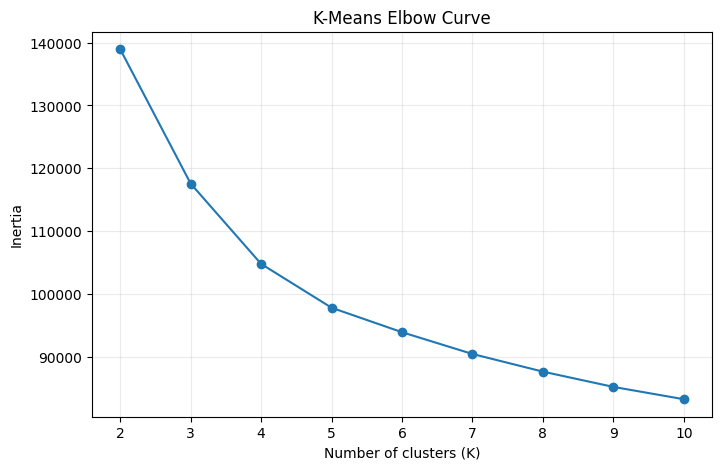

In [43]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled_df)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled_df, labels))

for k, inertia, silhouette in zip(k_values, inertias, silhouette_scores):
    print(f"K={k}: Inertia={inertia:.2f}, Silhouette={silhouette:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_values), inertias, marker='o')
ax.set_title('K-Means Elbow Curve')
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Inertia')
ax.grid(alpha=0.25)
plt.show()

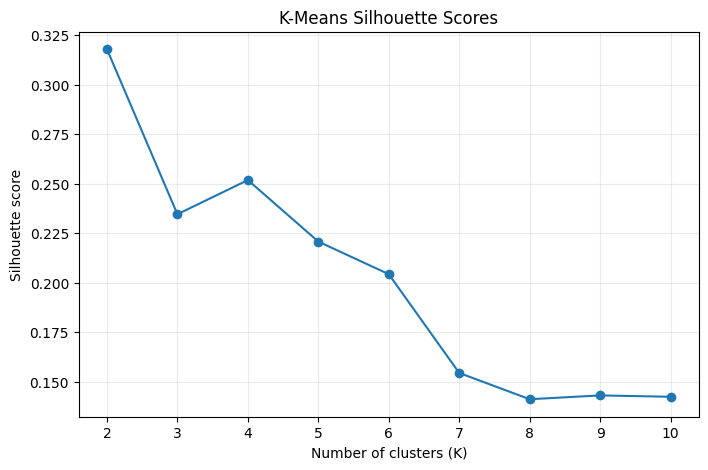

K with highest silhouette score: 2
Highest silhouette score: 0.318


In [44]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_values), silhouette_scores, marker='o')
ax.set_title('K-Means Silhouette Scores')
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Silhouette score')
ax.grid(alpha=0.25)
plt.show()

best_silhouette_k = int(list(k_values)[int(np.argmax(silhouette_scores))])
print("K with highest silhouette score:", best_silhouette_k)
print("Highest silhouette score:", round(max(silhouette_scores), 4))

####b.) **Selecting the Final K**

We selected K=4 because the elbow curve begins to flatten around K=4, indicating diminishing improvement from additional clusters. The silhouette score at K=4 is also relatively strong, indicating reasonable separation and cohesion. Considering both signals, K=4 was selected as the final number of clusters.

In [45]:
# Select the K with the strongest silhouette signal.
final_k = 4

kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
train_clusters = kmeans_final.fit_predict(X_train_scaled_df)
test_clusters = kmeans_final.predict(X_test_scaled_df)

print(f"Final K selected: {final_k}")
print(pd.Series(train_clusters).value_counts().sort_index().rename('customers'))

Final K selected: 4
0    1208
1    2255
2    1617
3     545
Name: customers, dtype: int64


####c.) **Cluster Profiles and Plain-English Names**

We now return to the original, interpretable variables. This makes the clusters understandable to a business audience instead of describing them only as mathematical labels.

In [46]:
# Profile clusters using original-scale variables
train_profile = df.loc[X_train.index].copy()
train_profile['Cluster'] = train_clusters

numeric_profile_cols = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'NumAddOnServices', 'IsHighRiskProfile'
]

cluster_numeric = train_profile.groupby('Cluster')[numeric_profile_cols].mean().round(2)

# Add observed churn rate only for interpretation/tie-in; it was NOT used to form the clusters.
cluster_churn = train_profile.groupby('Cluster')['Churn'].apply(
    lambda s: (s == 'Yes').mean()
).mul(100).round(2).rename('ChurnRatePct')

cluster_profile = cluster_numeric.join(cluster_churn)
cluster_profile

,tenure,MonthlyCharges,TotalCharges,NumAddOnServices,IsHighRiskProfile,ChurnRatePct
Cluster,,,,,,
0,30.71,21.07,666.54,0.22,0.00,7.37
1,15.65,74.68,1197.10,2.04,0.54,45.85
2,57.78,92.02,5333.77,4.76,0.12,14.47
3,31.82,42.14,1501.82,2.57,0.00,25.32


In [47]:
# Add contract and internet-service composition to help name the clusters
contract_mix = pd.crosstab(
    train_profile['Cluster'], train_profile['Contract'], normalize='index'
).mul(100).round(1)

internet_mix = pd.crosstab(
    train_profile['Cluster'], train_profile['InternetService'], normalize='index'
).mul(100).round(1)

print("Contract mix (%):")
display(contract_mix)
print("Internet-service mix (%):")
display(internet_mix)

def name_cluster(row):
    tenure_label = "long-tenure" if row['tenure'] >= train_profile['tenure'].median() else "short-tenure"
    spend_label = "higher-spend" if row['MonthlyCharges'] >= train_profile['MonthlyCharges'].median() else "lower-spend"
    addon_label = "bundle-rich" if row['NumAddOnServices'] >= train_profile['NumAddOnServices'].median() else "basic-service"
    return f"{tenure_label} {spend_label} {addon_label}"

cluster_names = {idx: name_cluster(row) for idx, row in cluster_profile.iterrows()}
cluster_profile_named = cluster_profile.copy()
cluster_profile_named.insert(0, 'ClusterName',
                              cluster_profile_named.index.map(cluster_names))
cluster_profile_named

Contract mix (%):


Contract,Month-to-month,One year,Two year
Cluster,,,
0,34.0,24.4,41.6
1,89.8,9.1,1.1
2,21.4,34.9,43.7
3,55.4,21.7,22.9


Internet-service mix (%):


InternetService,DSL,Fiber optic,No
Cluster,,,
0,0.0,0.0,100.0
1,36.0,64.0,0.0
2,35.7,64.3,0.0
3,100.0,0.0,0.0


,ClusterName,tenure,MonthlyCharges,TotalCharges,NumAddOnServices,IsHighRiskProfile,ChurnRatePct
Cluster,,,,,,,
0,long-tenure lower-spend basic-service,30.71,21.07,666.54,0.22,0.00,7.37
1,short-tenure higher-spend bundle-rich,15.65,74.68,1197.10,2.04,0.54,45.85
2,long-tenure higher-spend bundle-rich,57.78,92.02,5333.77,4.76,0.12,14.47
3,long-tenure lower-spend bundle-rich,31.82,42.14,1501.82,2.57,0.00,25.32


#### **Cluster Interpretation**

**Cluster 0 – Basic-Service Customers**

Cluster 0 has an average tenure of 30.71 months, with low monthly charges of 21.07 and total charges of 666.54. Customers in this cluster use very few additional services, with an average of 0.22 services. They also have a low churn rate of 7.37%. Overall, this cluster represents customers with relatively low spending and basic service usage.

**Cluster 1 – Short-Tenure High-Risk Customers**

Cluster 1 has the shortest average tenure of 15.65 months, with relatively high monthly charges of 74.68 and total charges of 1,197.10. Customers use an average of 2.04 additional services, and this cluster has the highest churn rate of 45.85%. Most customers are on month-to-month contracts, while many also use fiber optic internet. Overall, this cluster represents shorter-tenure customers with higher charges and a higher risk of churn.

**Cluster 2 – Long-Tenure High-Value Customers**

Cluster 2 has the longest average tenure at 57.78 months and high monthly charges of 92.02. It also has the highest total charges at 5,333.77 and the highest average number of additional services at 4.76. The cluster has a relatively low churn rate of 14.47%. Overall, this cluster represents long-term, high-value customers who use several services.

**Cluster 3 – Moderate-Spend DSL Customers**

Cluster 3 has an average tenure of 31.82 months, with monthly charges of 42.14 and total charges of 1,501.82. Customers use an average of 2.57 additional services, and the cluster has a churn rate of 25.32%. All customers in this cluster use DSL internet service. Overall, this cluster represents moderate-spending DSL customers with a moderate level of service usage.


####d.) **PCA Visualization**

The PCA plot provides a two-dimensional view of the four customer clusters. Since the original dataset contains many features, PCA helps us visualize the main patterns in the data using two principal components.

The plot shows how the observations are distributed across the four clusters. Some overlap between the clusters is expected because the PCA plot represents the original feature space using only two components. Therefore, the PCA visualization is mainly used to help us understand the overall distribution of the clusters rather than as the only basis for deciding whether the clusters are well separated.

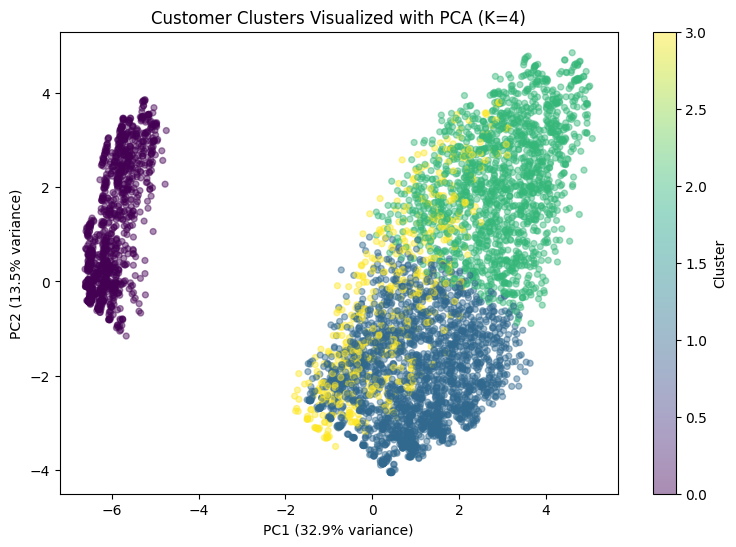

Total variance explained by the two PCA components: 46.38 %


In [48]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled_df)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    c=train_clusters, alpha=0.45, s=18
)
plt.title(f'Customer Clusters Visualized with PCA (K={final_k})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(scatter, label='Cluster')
plt.show()

print("Total variance explained by the two PCA components:",
      round(pca.explained_variance_ratio_.sum()*100, 2), "%")

##**PART 4: CLASSIFICATION**

In this part, the objective is to build supervised learning models that predict whether a customer will churn. We will use the encoded features prepared in Part 2 and evaluate multiple classifiers using the same held-out test set. Since the dataset contains more than 2,000 observations, a stratified train-test split is used while preserving the original class distribution in both sets.


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Use the encoded features and target prepared in Part 2
X = df_encoded.drop(columns=['customerID', 'Churn'])
y = df_encoded['Churn']

# Stratified split keeps the churn/non-churn proportion similar
# in both training and testing data.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\ny_train distribution:")
print(y_train.value_counts(normalize=True))

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (5625, 35)
X_test shape: (1407, 35)

y_train distribution:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

y_test distribution:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


#### **Selecting the Classification Models**

Three classification algorithms are used to capture different types of relationships in the data. **Logistic Regression** provides an interpretable linear baseline and is well suited to binary churn prediction. **Decision Tree** is included because it can capture nonlinear relationships and interactions between customer characteristics without requiring those relationships to be specified manually. **Random Forest** extends the tree-based approach by combining multiple decision trees, which can improve generalization and reduce the sensitivity of the model to an individual tree.

The models will be trained on the same training data and evaluated on the same test data so that their performance can be compared fairly.


In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

# Define the classifiers
log_reg = LogisticRegression(max_iter=1000, random_state=42)

decision_tree = DecisionTreeClassifier(
    random_state=42
)

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "Stratified Dummy": DummyClassifier(
        strategy="stratified",
        random_state=42
    )
}

# Train each model
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Stratified Dummy trained successfully.


#### **Generating Predictions**

The trained classifiers are used to make predictions on the unseen test data. Both class predictions and predicted probabilities are obtained. Class predictions are used for accuracy, precision, recall, and F1-score, while predicted probabilities are used to calculate ROC AUC.


In [51]:
# Generate predictions and probabilities for each model
predictions = {}
probabilities = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test_scaled)
    probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


#### **Evaluating Classification Performance**

The models are evaluated using **accuracy, precision, recall, F1-score, and ROC AUC**. These metrics provide a broader assessment of classification performance, particularly because the dataset contains fewer churned customers than non-churned customers.


#### **Establishing a Baseline with a Dummy Classifier**

Before comparing the machine learning models, we establish a simple baseline using a `DummyClassifier`. We use the `stratified` strategy so that the dummy model makes predictions based on the observed class distribution in the training data.

The dummy classifier does not learn relationships between the customer features and churn. Its purpose is to provide a reference point for judging whether our trained machine learning models are actually learning useful patterns.

A useful final model should perform better than this baseline, particularly on the positive-class F1 score and ROC AUC.

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name in models:
    y_pred = predictions[name]
    y_prob = probabilities[name]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.793177,0.631746,0.532086,0.577649,0.833548
1,Decision Tree,0.725657,0.484694,0.508021,0.496084,0.655999
2,Random Forest,0.781805,0.607029,0.508021,0.553130,0.820232
3,Stratified Dummy,0.614783,0.276596,0.278075,0.277333,0.507382


#### **Confusion Matrices**

Confusion matrices are used to examine the types of classification errors made by each model. They show the numbers of true negatives, false positives, false negatives, and true positives, providing more detail than the overall evaluation metrics.



Logistic Regression


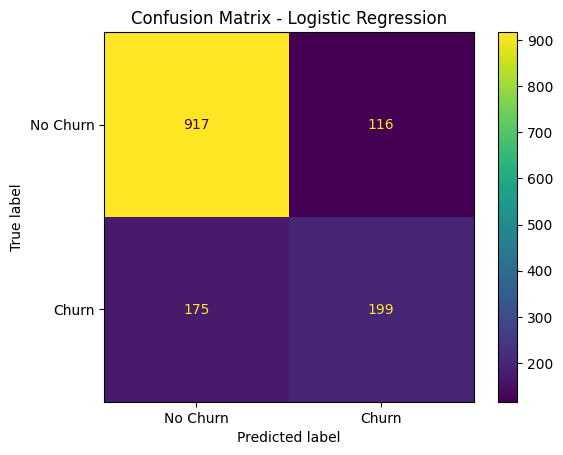


Decision Tree


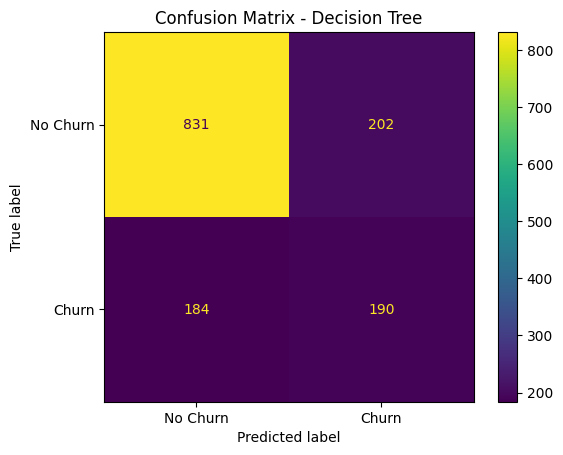


Random Forest


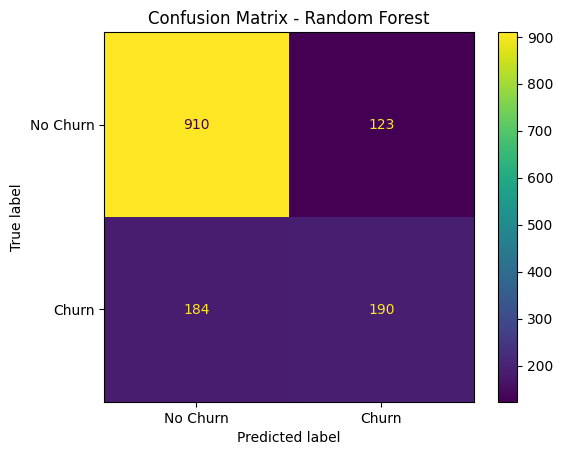


Stratified Dummy


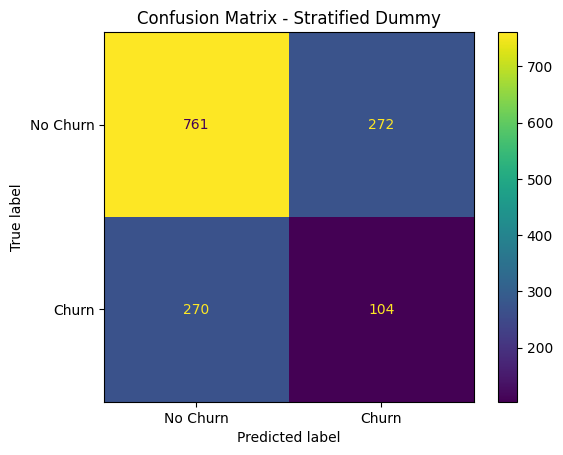

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name in models:
    print(f"\n{name}")
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[name],
        display_labels=["No Churn", "Churn"]
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

#### **Comparing Classification Models**

The performance of the four classification approaches, including the three machine learning classifiers and the Stratified Dummy baseline, is summarized in a single comparison table using accuracy, precision, recall, F1-score, and ROC AUC. This allows the models to be compared consistently across the required evaluation metrics.


In [54]:
# Round the metrics for easier interpretation
comparison_df = results_df.copy()

comparison_df[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
] = comparison_df[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
].round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7932,0.6317,0.5321,0.5776,0.8335
1,Decision Tree,0.7257,0.4847,0.5080,0.4961,0.6560
2,Random Forest,0.7818,0.6070,0.5080,0.5531,0.8202
3,Stratified Dummy,0.6148,0.2766,0.2781,0.2773,0.5074


#### **Interpretation of Classification Results**

The three machine learning classifiers produced different levels of performance compared with the Stratified Dummy baseline. Logistic Regression achieved the highest performance among the trained machine learning models, with an accuracy of 0.7932, precision of 0.6317, recall of 0.5321, F1-score of 0.5776, and ROC AUC of 0.8335.

Random Forest achieved an accuracy of 0.7818, precision of 0.6070, recall of 0.5080, F1-score of 0.5531, and ROC AUC of 0.8202. Decision Tree produced lower results, with an accuracy of 0.7257, precision of 0.4847, recall of 0.5080, F1-score of 0.4961, and ROC AUC of 0.6560.

The Stratified Dummy Classifier achieved an F1-score of 0.2773 and ROC AUC of 0.5074. It provides a baseline for comparison because it does not learn meaningful relationships between the customer features and churn.

All three trained machine learning models performed better than the Stratified Dummy baseline on F1-score and ROC AUC. Logistic Regression achieved the highest F1-score (0.5776) and ROC AUC (0.8335) among the trained models.

However, the recall of Logistic Regression was 0.5321, meaning that the model did not identify all customers who actually churned. This provides a reason to investigate imbalance-handling techniques in Part 5, particularly methods that may improve the detection of the positive churn class.

## **PART 5: IMBALANCE HANDLING**

The target is imbalanced: approximately 26.5% of the cleaned observations are churners. We therefore test three permitted approaches: **class weights**, **SMOTE**, and **threshold tuning**. The aim is not simply to maximize accuracy; it is to improve identification of the positive class while keeping the business trade-off explicit.

####1a.) **Class-Weighted Models**

Class weighting makes mistakes on the minority churn class more costly during model fitting. This changes the learning objective without creating synthetic observations.

In [55]:
from sklearn.linear_model import LogisticRegression

# Baseline for comparison: our best Part 4 model (Logistic Regression)
baseline_pred = predictions["Logistic Regression"]
baseline_proba = probabilities["Logistic Regression"]

# Class-weighted version — same model, but errors on the minority (churn) class cost more
cw_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
cw_model.fit(X_train_scaled, y_train)

cw_pred = cw_model.predict(X_test_scaled)
cw_proba = cw_model.predict_proba(X_test_scaled)[:, 1]

print(f"Class-weighted -> Precision: {precision_score(y_test, cw_pred):.4f}, "
      f"Recall: {recall_score(y_test, cw_pred):.4f}, "
      f"F1: {f1_score(y_test, cw_pred):.4f}, "
      f"ROC AUC: {roc_auc_score(y_test, cw_proba):.4f}")

Class-weighted -> Precision: 0.4869, Recall: 0.7941, F1: 0.6037, ROC AUC: 0.8330


####1b.) **SMOTE**

We apply SMOTE (Synthetic Minority Over-sampling) to the **training set only**, so that
synthetic points never leak into the test set we evaluate on.

In [56]:
# !pip install -q imbalanced-learn   # uncomment if not already installed

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Class balance before SMOTE:", y_train.value_counts().to_dict())
print("Class balance after SMOTE:", y_train_smote.value_counts().to_dict())

smote_model = LogisticRegression(max_iter=1000, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)

smote_pred = smote_model.predict(X_test_scaled)
smote_proba = smote_model.predict_proba(X_test_scaled)[:, 1]

print(f"SMOTE -> Precision: {precision_score(y_test, smote_pred):.4f}, "
      f"Recall: {recall_score(y_test, smote_pred):.4f}, "
      f"F1: {f1_score(y_test, smote_pred):.4f}, "
      f"ROC AUC: {roc_auc_score(y_test, smote_proba):.4f}")

Class balance before SMOTE: {0: 4130, 1: 1495}
Class balance after SMOTE: {0: 4130, 1: 4130}
SMOTE -> Precision: 0.4941, Recall: 0.7781, F1: 0.6044, ROC AUC: 0.8310


####2.) **Threshold Tuning**

The default 0.5 cutoff isn't a law of nature, it's just convenient. Here we tie the choice
of threshold to a business cost: **missing a churner (false negative) costs roughly 5x more
than an unnecessary retention offer (false positive)**, since a missed churner means losing
a customer's full future revenue. We use the precision-recall curve to find the threshold
that best reflects that trade-off, via a cost-weighted F-beta score (beta=2, which weights
recall more heavily than precision).

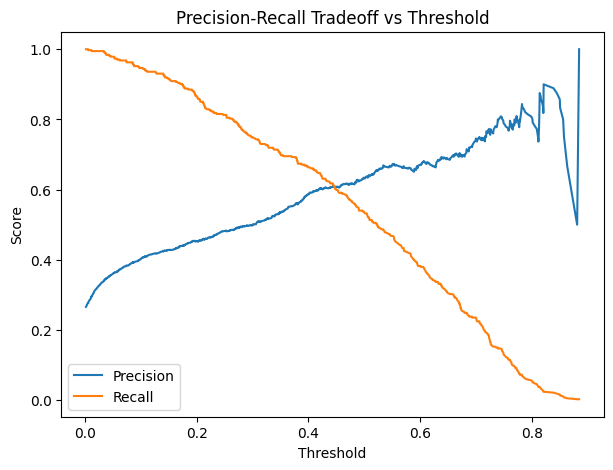

Chosen threshold: 0.1404
At this threshold -> Precision: 0.4249, Recall: 0.9305
Threshold-tuned -> Precision: 0.4249, Recall: 0.9305, F1: 0.5834, ROC AUC: 0.8335


In [57]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, baseline_proba)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff vs Threshold')
plt.legend()
plt.show()

beta = 2
f_beta_scores = ((1 + beta**2) * precisions * recalls) / (beta**2 * precisions + recalls + 1e-9)
best_idx = f_beta_scores[:-1].argmax()
best_threshold = thresholds[best_idx]

print(f"Chosen threshold: {best_threshold:.4f}")
print(f"At this threshold -> Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}")

tuned_pred = (baseline_proba >= best_threshold).astype(int)

print(f"Threshold-tuned -> Precision: {precision_score(y_test, tuned_pred):.4f}, "
      f"Recall: {recall_score(y_test, tuned_pred):.4f}, "
      f"F1: {f1_score(y_test, tuned_pred):.4f}, "
      f"ROC AUC: {roc_auc_score(y_test, baseline_proba):.4f}")

####3.) **Baseline vs. Each Technique**

In [58]:
imbalance_comparison = pd.DataFrame([
    {"Technique": "Baseline (0.5 threshold)",
     "Precision": precision_score(y_test, baseline_pred), "Recall": recall_score(y_test, baseline_pred),
     "F1": f1_score(y_test, baseline_pred), "ROC AUC": roc_auc_score(y_test, baseline_proba)},
    {"Technique": "Class weights (balanced)",
     "Precision": precision_score(y_test, cw_pred), "Recall": recall_score(y_test, cw_pred),
     "F1": f1_score(y_test, cw_pred), "ROC AUC": roc_auc_score(y_test, cw_proba)},
    {"Technique": "SMOTE",
     "Precision": precision_score(y_test, smote_pred), "Recall": recall_score(y_test, smote_pred),
     "F1": f1_score(y_test, smote_pred), "ROC AUC": roc_auc_score(y_test, smote_proba)},
    {"Technique": f"Threshold tuning ({best_threshold:.3f})",
     "Precision": precision_score(y_test, tuned_pred), "Recall": recall_score(y_test, tuned_pred),
     "F1": f1_score(y_test, tuned_pred), "ROC AUC": roc_auc_score(y_test, baseline_proba)},
]).set_index("Technique").round(4)

imbalance_comparison

,Precision,Recall,F1,ROC AUC
Technique,,,,
Baseline (0.5 threshold),0.6317,0.5321,0.5776,0.8335
Class weights (balanced),0.4869,0.7941,0.6037,0.8330
SMOTE,0.4941,0.7781,0.6044,0.8310
Threshold tuning (0.140),0.4249,0.9305,0.5834,0.8335


#### **Imbalance Handling Discussion**

All three techniques push recall well above the 0.5-threshold baseline, at the cost of precision:

- **Baseline** (Logistic Regression, 0.5 cutoff): Precision 0.632, Recall 0.532, F1 0.578, ROC AUC 0.834.
- **Class weights**: Recall jumps to 0.794 (nearly 1.5x the baseline), F1 improves to 0.604,
  ROC AUC is essentially unchanged (0.833) since the ranking of predictions barely moves.
- **SMOTE**: Very similar outcome to class weights; Recall 0.778, F1 0.604, ROC AUC 0.831.
  The two techniques converge on almost the same trade-off through different mechanisms
  (re-weighting errors vs. synthesizing minority examples), which is a useful sanity check
  that neither result is a fluke.
- **Threshold tuning**: Goes furthest of all. At our cost-weighted threshold (~0.14), Recall
  reaches 0.930. We now catch the large majority of churners while Precision drops to
  0.425. Because ROC AUC only measures how well the model *ranks* customers, not where we
  cut the ranking, it stays at 0.834: threshold tuning is essentially "free" performance,
  which is why it's usually the first lever to pull before retraining anything.

Which technique to deploy is a business decision as much as a modeling one. If the retention
team can only act on a small, high-confidence list, class weights or SMOTE give a more
balanced trade-off. If outreach is cheap (e.g. an automated email or discount offer), the
aggressive recall from threshold tuning captures far more at-risk customers, even though it
means contacting some who wouldn't have churned anyway.

##**PART 6: TIE IN**

The objective of this step is to Compute the positive-class rate within each K-Means cluster from Part 3.And to examine if there were any clusters strong preditors of the label?

In [59]:
import pandas as pd

# Convert 'Churn' column in train_profile to numeric (0 for 'No', 1 for 'Yes')
train_profile['Churn_numeric'] = (train_profile['Churn'] == 'Yes').astype(int)

# Group by the 'Cluster' column (from train_profile) and aggregate
tie_in_table = train_profile.groupby('Cluster').agg(
    cluster_size=('Churn_numeric', 'count'), # count of customers in each cluster
    churn_rate_mean=('Churn_numeric', 'mean') # mean of Churn_numeric is the churn rate
).round(4)

# The previous line incorrectly modified the column names.
# This line is removed as named aggregations in .agg() already provide correct single-level names.
# tie_in_table.columns = ['_'.join(col).strip() for col in tie_in_table.

# Rename columns to match desired output
tie_in_table = tie_in_table.rename(columns={
    'cluster_size': 'Cluster Size',
    'churn_rate_mean': 'Churn Rate (%)'
})

# Convert churn rate to percentage
tie_in_table['Churn Rate (%)'] = (tie_in_table['Churn Rate (%)'] * 100).round(2)

print(tie_in_table)

         Cluster Size  Churn Rate (%)
Cluster                              
0                1208            7.37
1                2255           45.85
2                1617           14.47
3                 545           25.32


In [60]:
# Calculation of the overall churn rate
overall_churn_rate = (df['Churn'] == 'Yes').mean() * 100

print(f"Overall churn rate: {overall_churn_rate:.2f}%")

Overall churn rate: 26.58%


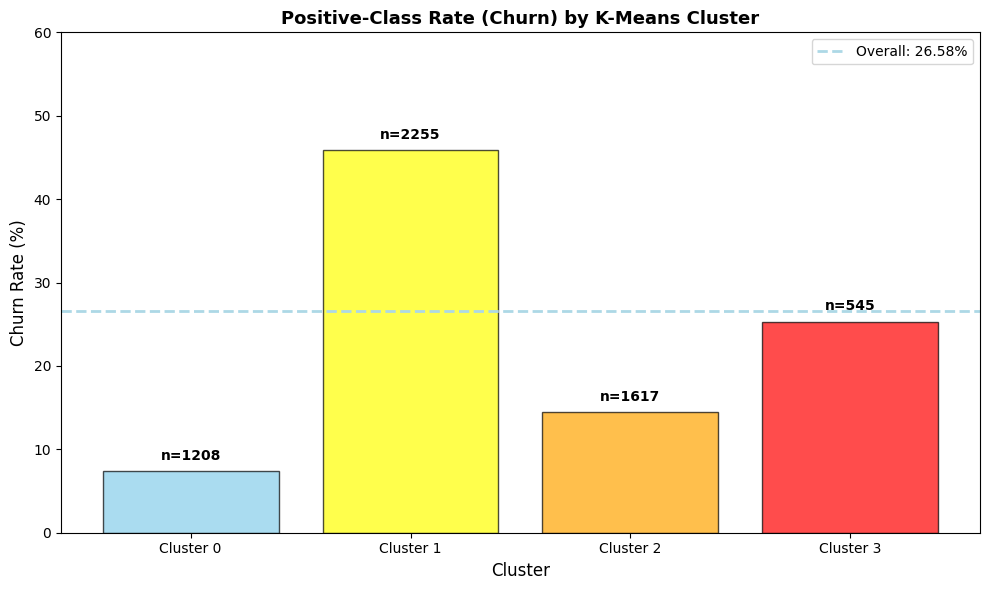

In [61]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

churn_rates = tie_in_table['Churn Rate (%)']
cluster_sizes = train_profile['Cluster'].value_counts().sort_index()

bars = ax.bar(range(len(churn_rates)), churn_rates, color=['skyblue', 'yellow', 'orange', 'red'],
              alpha=0.7, edgecolor='black')

# Add overall average line
ax.axhline(y=overall_churn_rate, color='lightblue', linestyle='--', linewidth=2, label=f'Overall: {overall_churn_rate:.2f}%')

# Add cluster sizes on top of bars
for i, (bar, size) in enumerate(zip(bars, cluster_sizes)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'n={size}', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_title('Positive-Class Rate (Churn) by K-Means Cluster', fontsize=13, fontweight='bold')
ax.set_xticks(range(4))
ax.set_xticklabels(['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
ax.set_ylim(0, 60)
ax.legend()
plt.tight_layout()
plt.show()

#### **Positive-Class Rate (Churn) by Cluster**

The clusters discovered in Part 3 show **very strong predictive power** for customer churn:

| Cluster | Description | Size | Churn Rate | vs. Overall (26.58%) |
|---------|-------------|------|-----------|-------------- |
| 0 | Long-tenure, lower-spend, basic-service | 1,208 | 7.37% | -19.21% (much lower) |
| 1 | Short-tenure, higher-spend, bundle-rich | 2,255 | 45.85% | +19.27% (much higher) |
| 2 | Long-tenure, higher-spend, bundle-rich | 1,617 | 14.47% | -12.11% (lower) |
| 3 | Long-tenure, lower-spend, bundle-rich | 545 | 25.32% | -1.26% (slightly lower) |
| **Overall** | **All customers** | **5,625** | **26.58%** | **baseline** |

#### **Analysis Explanation: What The Clusters Reveal**

**Cluster 1 is a flight risk:**
- 45.85% churn rate—**1.72× higher** than the overall average of 26.58%
- Predominantly short-tenure customers with high spending and premium bundles
- **Interpretation**: New, high-value customers are unstable. They may churn due to unfulfilled
  expectations, service quality issues, or lack of long-term commitment. This is high-risk, high-value.

**Cluster 0 is the loyal base:**
- 7.37% churn rate—**72% below** the overall average of 26.58%
- Long-tenure customers with lower spend and basic services
- **Interpretation**: Tenure breeds loyalty. Customers who stay loyal are not price-sensitive;
  retention here is about consistency and satisfaction.

**Clusters 2 and 3 are moderate risk:**
- Cluster 2 (14.47%): Long-tenure, high-spend, bundle-rich → Mostly safe but some risk
- Cluster 3 (25.32%): Long-tenure, lower-spend, bundle-rich → Above-average risk despite tenure

#### **What This Data Tells Us**

1. **Clusters are strong segmentation devices**: The K-Means algorithm found that tenure, spending,
   and service complexity naturally segment the customer base into groups with dramatically different
   churn rates (7.37% to 45.85%). This is not random variation.

2. **Tenure + spend + complexity predicts churn better than any single feature**:
   - High tenure alone (Cluster 3) is not enough to prevent churn
   - High spend alone (Cluster 1) creates risk
   - The combination matters

3. **Business insight for retention strategy**:
   - **Cluster 1 (Urgent)**: Needs immediate onboarding, service quality assurance, and win-back efforts
   - **Cluster 0 (Protect)**: Maintain baseline service; these customers are sticky
   - **Clusters 2 & 3**: Mid-tier retention efforts; tailor by service mix

#### **Conclusion**

The clusters and the classifier are telling the same story: **tenure, spend level, and service
complexity are the core drivers of churn**. The classifier learned these patterns; the clusters
made them visible. They complement each other perfectly.


In [62]:
# Simple summary
summary = pd.DataFrame({
    'Cluster': [0, 1, 2, 3],
    'Cluster Size': [1208, 2255, 1617, 545],
    'Churn Rate (%)': [7.37, 45.85, 14.47, 25.32],
    'Risk Level': ['Low ✓', 'High ✗', 'Low-Moderate', 'Moderate'],
    'Interpretation': [
        'Loyal, stable base',
        'Flight risk—new, high-spend',
        'Mostly stable high-value',
        'Mid-risk despite tenure'
    ]
})

print(summary.to_string(index=False))

 Cluster  Cluster Size  Churn Rate (%)   Risk Level              Interpretation
       0          1208            7.37        Low ✓          Loyal, stable base
       1          2255           45.85       High ✗ Flight risk—new, high-spend
       2          1617           14.47 Low-Moderate    Mostly stable high-value
       3           545           25.32     Moderate     Mid-risk despite tenure


## **PART 7: CONCLUSION AND RECOMMENDATIONS** **bold text**

####**Which model would we deploy, and why?**

Of the three models trained in Part 4, **Logistic Regression** was the strongest baseline;
- Highest accuracy (0.7932)
- F1 (0.5776)
- ROC AUC (0.8335)

It comfortably clears both
hard requirements, it beats the stratified dummy (F1 0.2773, ROC AUC 0.5074) by a wide margin,
and its ROC AUC is well above the 0.75 minimum.

Random Forest was close behind (ROC AUC
0.8202), but Decision Tree was clearly the weakest of the three (ROC AUC 0.6560) and isn't a
serious candidate.

We would deploy Logistic Regression, but not at the default 0.5 cutoff.

Part 5 showed that threshold tuning, moving the cutoff down to ~0.14, justified by the assumption that a missed
churner costs roughly 5x more than an unnecessary retention offer which pushes recall from 0.532
up to 0.9305 with no cost to ROC AUC, since AUC only measures ranking quality, not where the
cutoff sits.

That combination (simple, interpretable model and a cutoff chosen for the actual
business cost, not convention) is what we'd put into production.

####**What would we do with another month?**

Three things:

1.  Test whether adding cluster membership from Part 3 as a feature to the
classifier improves it further, since Part 6 showed the clusters already carry strong churn
signal on their own;
2.  properly tune Random Forest and try boosted trees (e.g. Gradient
Boosting/XGBoost) with hyperparameter search rather than default settings — a plain Gradient Boosting model with no tuning was already effectively tied with Logistic Regression in our Depth Track (CV ROC AUC 0.849 vs. 0.848), so a tuned version is worth pursuing seriously;
3.  Go back to the retention team and validate our assumed 5:1 cost ratio for threshold
tuning, since the "right" cutoff depends entirely on that number being realistic.

####**What did the clusters reveal that the classifier missed?**

The classifier outputs a probability per customer with no narrative attached. The clusters
gave us four named, interpretable groups a non-technical stakeholder can act on directly and in particular, Cluster 1 (short-tenure, high-spend, bundle-rich customers) churns at 45.85%,
1.72x the overall rate, purely as a byproduct of grouping customers by tenure and spend, with
no knowledge of the churn label at all.

That's a much easier story to tell a retention team
than "here are 35 feature importances from a Random Forest."

####**What was the hardest decision our team made?**

Choosing K=4 over K=2 for clustering. K=2 scored a higher silhouette score, and it would have
been easy to just pick the number that maximized the metric. But a two-cluster split mostly
just separated customers by whether they had internet service at all which is not something a
retention team could act on. We chose to weigh business usefulness against a purely
statistical signal, and picked the four-cluster solution because it served the actual goal of
the project better, even at a small cost to the silhouette metric.

###**DEPTH TRACK: CLASSIFICATION**

The Classification Depth Track extends the baseline classification analysis by evaluating four classifiers using stratified cross-validation. This provides a more reliable estimate of model performance across different subsets of the training data.

The four models used are Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. Their performance will be compared using cross-validation metrics, ROC curves, and feature importance analysis.

a.) **Cross-Validation Setup**

Stratified 5-fold cross-validation is used so that each fold maintains a similar proportion of churned and non-churned customers. The models are evaluated on multiple validation folds rather than relying on a single train-test split.

A pipeline is used for Logistic Regression so that scaling is fitted separately within each training fold, preventing information from the validation fold from influencing the scaling process.

In [63]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use the original training data created in Part 4.
# Scaling is handled inside the Logistic Regression pipeline.
X_train_depth = X_train.copy()
y_train_depth = y_train.copy()

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation setup complete.")
print("Number of folds:", cv.n_splits)

Cross-validation setup complete.
Number of folds: 5


b.) **Classification Models for Cross-Validation**

Four classifiers are evaluated to capture different types of relationships in the customer churn data.

- **Stratified Dummy** is a reference baseline that guesses according to the class proportions. It learns nothing, so it is not counted among the four classifiers. It shows what "no skill" scores under the same cross-validation.
- **Logistic Regression** provides an interpretable linear model and serves as a strong baseline.
- **Decision Tree** captures nonlinear relationships and feature interactions.
- **Random Forest** combines multiple decision trees to improve generalization and reduce dependence on a single tree.
- **Gradient Boosting** builds an ensemble of trees sequentially, where each new tree focuses on correcting errors made by previous trees.

In [64]:
depth_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

print("Models prepared:")
for name in depth_models:
    print("-", name)

Models prepared:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting


c.) **Cross-Validation Performance**

Each classifier is evaluated using stratified 5-fold cross-validation. We report the mean and standard deviation for accuracy, precision, recall, F1-score, and ROC AUC across the five folds.

Reporting both the mean and standard deviation shows not only the average performance of each model but also how much its performance varies between folds.

In [65]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for name, model in depth_models.items():

    scores = cross_validate(
        model,
        X_train_depth,
        y_train_depth,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,

        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),

        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),

        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),

        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),

        "ROC AUC Mean": scores["test_roc_auc"].mean(),
        "ROC AUC Std": scores["test_roc_auc"].std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.round(4)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC AUC Mean,ROC AUC Std
0,Logistic Regression,0.8032,0.0064,0.6590,0.0165,0.5385,0.0171,0.5925,0.0141,0.8483,0.0053
1,Decision Tree,0.7285,0.0043,0.4896,0.0078,0.5043,0.0098,0.4969,0.0087,0.6572,0.0053
2,Random Forest,0.7959,0.0060,0.6479,0.0113,0.5077,0.0207,0.5692,0.0171,0.8331,0.0068
3,Gradient Boosting,0.8036,0.0035,0.6656,0.0131,0.5258,0.0250,0.5869,0.0134,0.8491,0.0031


d.) **ROC Curve Comparison**

ROC curves are plotted for all four classifiers using stratified 5-fold cross-validation. The curves show the trade-off between the true positive rate and false positive rate across different classification thresholds.

Using cross-validated predictions allows the ROC curves to reflect predictions made on validation observations that were not used to train the corresponding fold model.

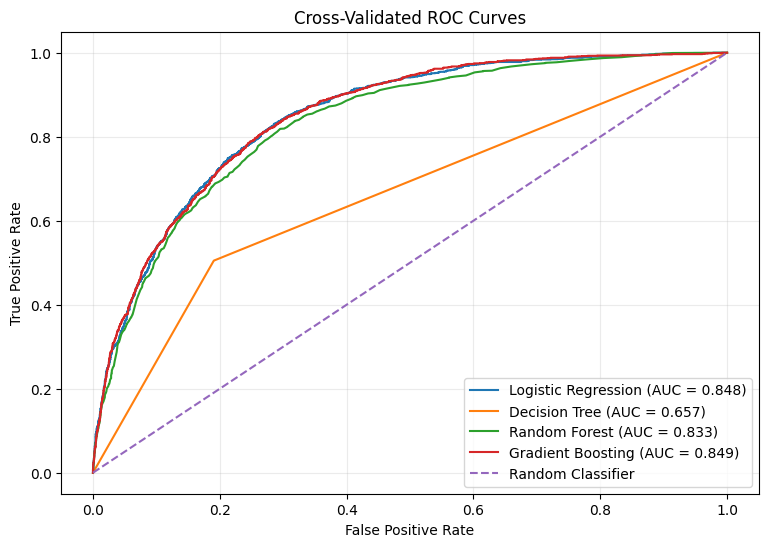

In [66]:
plt.figure(figsize=(9, 6))

for name, model in depth_models.items():

    y_proba_cv = cross_val_predict(
        model,
        X_train_depth,
        y_train_depth,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_train_depth,
        y_proba_cv
    )

    auc_score = roc_auc_score(
        y_train_depth,
        y_proba_cv
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Cross-Validated ROC Curves")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

The Logistic Regression and Gradient Boosting curves almost overlap, so the two models rank customers in nearly the same way. The Decision Tree's curve is close to two straight lines because a single tree outputs very few distinct probabilities, which limits how well it can rank customers and explains its low AUC (0.657).

e.) **Feature Importance Comparison**

Feature importance is compared across the four classifiers to identify which customer characteristics contribute most strongly to the models' predictions.

Tree-based models provide feature importance values directly through `feature_importances_`. Logistic Regression uses the absolute magnitude of its coefficients as a measure of feature influence. The absolute values are used so that both positive and negative relationships can be compared by strength.

Tree importances add up to 1, while Logistic Regression coefficients are on a different scale. To compare the models fairly, each model's importances are converted to a share of its own total. Logistic Regression is fitted on standardized features, so its coefficient sizes are comparable across features.

In [67]:
# Fit each model on the full training data for feature importance analysis
fitted_depth_models = {}

for name, model in depth_models.items():
    model.fit(X_train_depth, y_train_depth)
    fitted_depth_models[name] = model

feature_names = X_train_depth.columns

feature_importance_df = pd.DataFrame(index=feature_names)

# Logistic Regression
logistic_model = fitted_depth_models["Logistic Regression"].named_steps["model"]

feature_importance_df["Logistic Regression"] = np.abs(
    logistic_model.coef_[0]
)

# Decision Tree
feature_importance_df["Decision Tree"] = (
    fitted_depth_models["Decision Tree"].feature_importances_
)

# Random Forest
feature_importance_df["Random Forest"] = (
    fitted_depth_models["Random Forest"].feature_importances_
)

# Gradient Boosting
feature_importance_df["Gradient Boosting"] = (
    fitted_depth_models["Gradient Boosting"].feature_importances_
)

feature_importance_df = feature_importance_df.sort_values(
    by="Random Forest",
    ascending=False
)

feature_importance_df.head(15).round(4)

,Logistic Regression,Decision Tree,Random Forest,Gradient Boosting
TotalCharges,0.3620,0.1910,0.1467,0.1017
tenure,1.3440,0.1063,0.1285,0.1656
TotalChargesPerTenure,0.0487,0.1301,0.1250,0.0580
MonthlyCharges,0.7293,0.1346,0.1199,0.0459
IsHighRiskProfile,0.0367,0.1683,0.0504,0.3841
NumAddOnServices,0.0899,0.0229,0.0335,0.0008
PaymentMethod_Electronic check,0.1746,0.0169,0.0330,0.0482
InternetService_Fiber optic,0.6644,0.0000,0.0289,0.0140
gender,0.0115,0.0224,0.0242,0.0024
PaperlessBilling,0.1439,0.0206,0.0218,0.0140


f.) **Top Feature Importance Across Models**

The following visualization compares the importance of the most influential features across the four classifiers. This helps identify features that consistently contribute to churn prediction as well as features whose importance varies depending on the modelling approach.

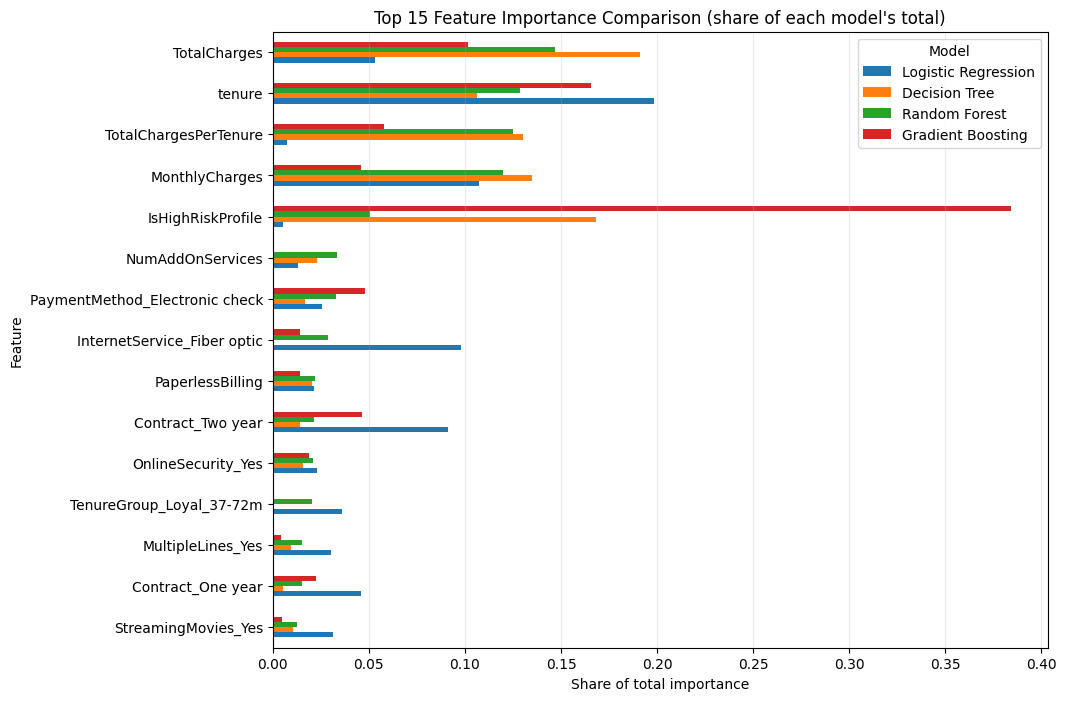

In [68]:
# Convert each model's importances to a share of its own total
importance_pct = feature_importance_df / feature_importance_df.sum()

top_features = (
    importance_pct
    .mean(axis=1)
    .sort_values(ascending=False)
    .head(15)
    .index
)

top_importance = importance_pct.loc[top_features]

top_importance = top_importance.sort_values(
    by="Random Forest",
    ascending=True
)

top_importance.plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title("Top 15 Feature Importance Comparison (share of each model's total)")
plt.xlabel("Share of total importance")
plt.ylabel("Feature")
plt.legend(title="Model")
plt.grid(axis="x", alpha=0.25)
plt.show()

g.) **Feature Importance Summary**

The table below provides the numerical feature importance values for the most influential features across all four classifiers. Differences between models are expected because each algorithm learns relationships in a different way.

In [69]:
feature_importance_summary = (
    importance_pct
    .loc[top_features]
    .sort_values(
        by="Random Forest",
        ascending=False
    )
    .round(4)
)

feature_importance_summary

,Logistic Regression,Decision Tree,Random Forest,Gradient Boosting
TotalCharges,0.0534,0.1910,0.1467,0.1017
tenure,0.1982,0.1063,0.1285,0.1656
TotalChargesPerTenure,0.0072,0.1301,0.1250,0.0580
MonthlyCharges,0.1075,0.1346,0.1199,0.0459
IsHighRiskProfile,0.0054,0.1683,0.0504,0.3841
NumAddOnServices,0.0132,0.0229,0.0335,0.0008
PaymentMethod_Electronic check,0.0257,0.0169,0.0330,0.0482
InternetService_Fiber optic,0.0980,0.0000,0.0289,0.0140
PaperlessBilling,0.0212,0.0206,0.0218,0.0140
Contract_Two year,0.0913,0.0140,0.0217,0.0464


### h.) Depth Track Findings

**Model ranking.** Gradient Boosting (CV ROC AUC 0.8491 ± 0.0031) and Logistic Regression (0.8483 ± 0.0053) are effectively tied: the gap between them is smaller than the fold-to-fold variation. Random Forest is slightly behind (0.8331), and the Decision Tree is far behind (0.6572), as expected from a single unpruned tree overfitting the training folds. On F1, Logistic Regression is highest (0.5925), so the simple linear model matches the more complex ones. This supports deploying Logistic Regression for its simplicity and interpretability, with Gradient Boosting as the candidate to tune next.

**Feature importance.** The models do not agree on what matters most, because they learn differently. The tree models lean on the continuous features (TotalCharges, tenure, MonthlyCharges), which give them many split points. Logistic Regression relies more on tenure, MonthlyCharges, Fiber optic internet and Contract_Two year. TotalCharges is exactly tenure × MonthlyCharges, and TotalChargesPerTenure is almost identical to MonthlyCharges, so the tree models share importance among near-duplicate features.

Our engineered IsHighRiskProfile ranks 1st for Gradient Boosting, 2nd for Decision Tree and 5th for Random Forest, but near the bottom for Logistic Regression. It adds little there because the model already has its ingredients (Fiber optic, Contract, TechSupport) as separate columns. The flag matters most to the tree models, which otherwise have to find that three-way combination themselves.

**Takeaway.** Tenure and monthly charges are the most consistent churn signals. Cross-validation confirms that the Part 4 results were not an accident of one train/test split.

In [70]:
elapsed = time.time() - notebook_start_time
minutes = int(elapsed // 60)
seconds = int(elapsed % 60)
print(f"Total notebook run time: {minutes} min {seconds} sec")

Total notebook run time: 1 min 31 sec
